In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("campuspulse_akgec_cleaned.csv")

print(df.shape)

(200000, 37)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 37 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   complaint_id                 200000 non-null  str    
 1   complaint_date               200000 non-null  str    
 2   complaint_time               200000 non-null  str    
 3   complainant_type             200000 non-null  str    
 4   department                   197521 non-null  str    
 5   year_of_study                89366 non-null   float64
 6   campus_zone                  200000 non-null  str    
 7   building                     200000 non-null  str    
 8   floor                        197785 non-null  str    
 9   room_lab_no                  198084 non-null  str    
 10  facility_type                198037 non-null  str    
 11  class_section                196152 non-null  str    
 12  issue_category               200000 non-null  str    
 13  issue_subc

In [4]:
df.describe()

,year_of_study,affected_users,issue_duration_hours,previous_similar_complaints,complaints_last_7_days,complaints_last_30_days,recurrence_count,equipment_age_years,infrastructure_age_years,estimated_repair_cost,response_time_hours,resolution_time_hours,actual_expenditure
count,89366.000000,200000.000000,191020.000000,192032.000000,190963.000000,189810.000000,200000.000000,189777.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,2.394132,106.660680,27.829809,1.883040,0.755497,2.627132,2.689355,6.157403,13.037879,14460.473585,14.365660,17.464744,33870.124535
std,1.096067,340.108845,35.114901,1.421927,0.854844,1.994324,2.206767,3.346032,5.533061,18173.985943,10.036313,8.296217,54252.294084
min,1.000000,1.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,146.000000,0.500000,4.100000,122.000000
25%,1.000000,20.000000,8.840000,1.000000,0.000000,1.000000,1.000000,3.800000,9.200000,4435.000000,7.170000,11.620000,7404.000000
50%,2.000000,39.000000,17.120000,2.000000,1.000000,2.000000,2.000000,6.000000,13.000000,8832.000000,11.980000,16.140000,16734.500000
75%,3.000000,77.000000,33.210000,3.000000,1.000000,4.000000,4.000000,8.300000,16.800000,17573.000000,18.800000,21.850000,38019.250000
max,4.000000,4999.000000,500.000000,10.000000,8.000000,18.000000,19.000000,15.000000,35.000000,424990.000000,72.000000,100.560000,750000.000000


In [5]:
df.nunique().sort_values()

year_of_study                       4
severity                            4
operational_impact                  4
connectivity_impact                 4
safety_risk                         4
academic_impact                     4
priority                            4
complainant_type                    5
complaint_status                    6
submission_channel                  6
weather_condition                   6
floor                               6
complaints_last_7_days              9
maintenance_team                   10
campus_zone                        11
previous_similar_complaints        11
resolution_type                    11
facility_type                      13
department                         14
issue_category                     15
building                           17
complaints_last_30_days            19
recurrence_count                   20
class_section                      48
room_lab_no                        58
issue_subcategory                  75
equipment_ag

In [6]:
df.dtypes

complaint_id                       str
complaint_date                     str
complaint_time                     str
complainant_type                   str
department                         str
year_of_study                  float64
campus_zone                        str
building                           str
floor                              str
room_lab_no                        str
facility_type                      str
class_section                      str
issue_category                     str
issue_subcategory                  str
severity                           str
affected_users                   int64
issue_duration_hours           float64
previous_similar_complaints    float64
complaints_last_7_days         float64
complaints_last_30_days        float64
recurrence_count                 int64
equipment_age_years            float64
infrastructure_age_years       float64
connectivity_impact                str
safety_risk                        str
academic_impact          

In [7]:
df["priority"].value_counts()

priority
Medium      70197
Low         68808
High        42242
Critical    18753
Name: count, dtype: int64

In [8]:
df["priority"].value_counts(normalize=True) * 100

priority
Medium      35.0985
Low         34.4040
High        21.1210
Critical     9.3765
Name: proportion, dtype: float64

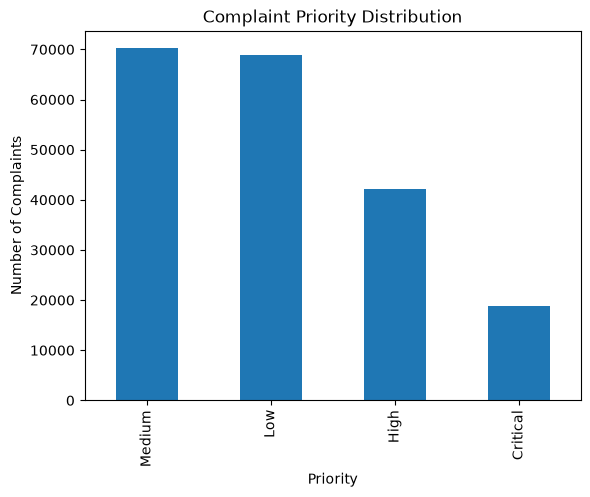

In [9]:
df["priority"].value_counts().plot(kind="bar")

plt.title("Complaint Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Complaints")
plt.show()

In [10]:
missing = df.isnull().sum().sort_values(ascending=False)

print(missing[missing > 0])

connectivity_impact            156996
year_of_study                  110634
safety_risk                     88296
operational_impact              75840
academic_impact                 69964
submission_channel              10594
equipment_age_years             10223
complaints_last_30_days         10190
complaints_last_7_days           9037
issue_duration_hours             8980
issue_subcategory                8398
previous_similar_complaints      7968
weather_condition                7607
class_section                    3848
department                       2479
floor                            2215
facility_type                    1963
room_lab_no                      1916
dtype: int64


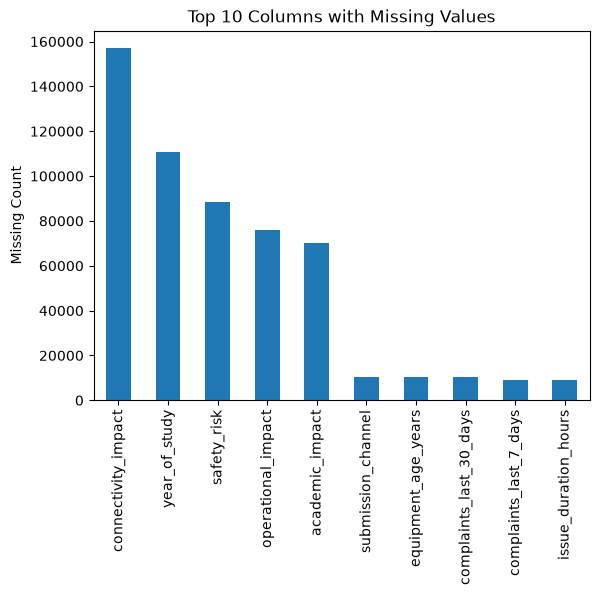

In [11]:
missing.head(10).plot(kind="bar")

plt.title("Top 10 Columns with Missing Values")
plt.ylabel("Missing Count")
plt.show()

In [12]:
cat_cols = df.select_dtypes("object").columns
print(cat_cols.tolist())

['complaint_id', 'complaint_date', 'complaint_time', 'complainant_type', 'department', 'campus_zone', 'building', 'floor', 'room_lab_no', 'facility_type', 'class_section', 'issue_category', 'issue_subcategory', 'severity', 'connectivity_impact', 'safety_risk', 'academic_impact', 'operational_impact', 'weather_condition', 'submission_channel', 'complaint_status', 'maintenance_team', 'resolution_type', 'priority']


C:\Users\adity\AppData\Local\Temp\ipykernel_13248\2939085853.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes("object").columns


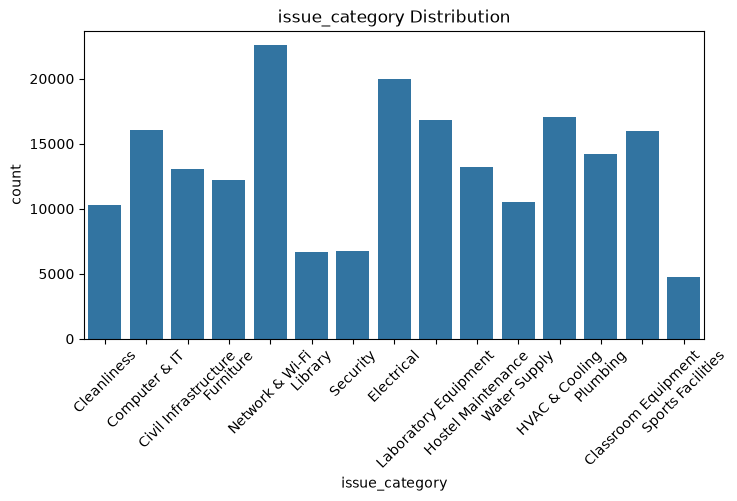

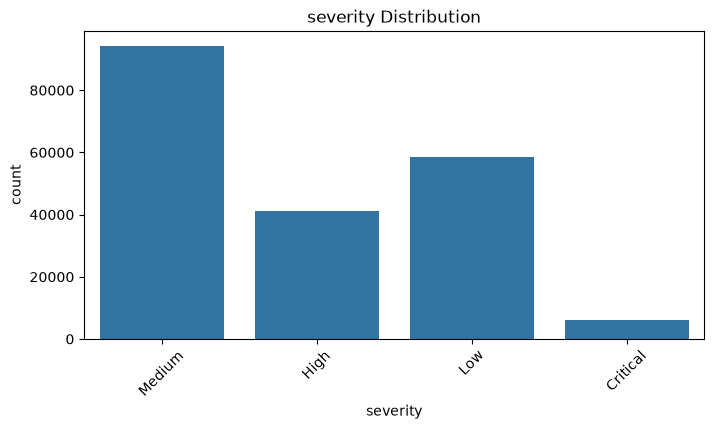

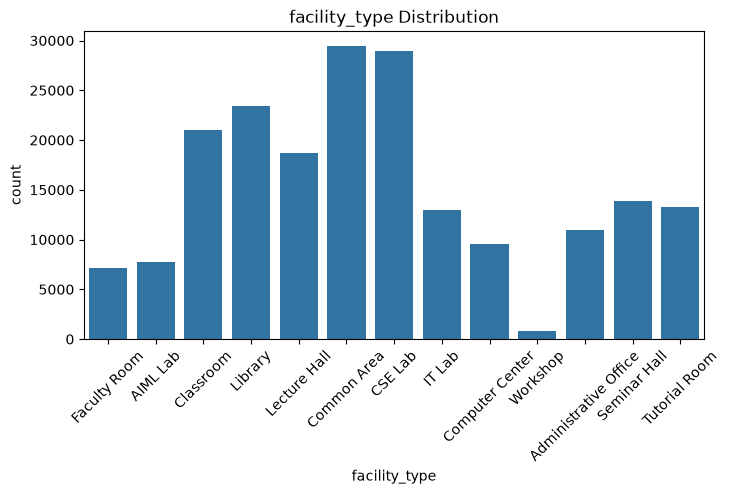

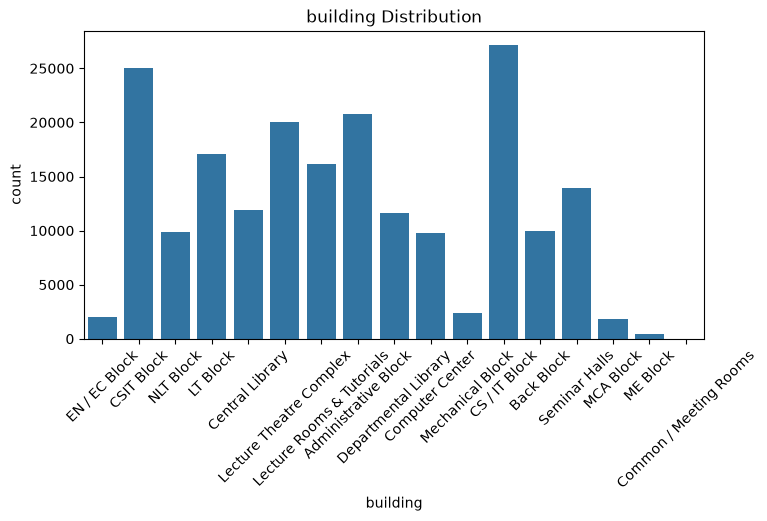

In [13]:
cols = ["issue_category", "severity", "facility_type", "building"]

for col in cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

In [14]:
num_cols = df.select_dtypes("number").columns
print(num_cols.tolist())

['year_of_study', 'affected_users', 'issue_duration_hours', 'previous_similar_complaints', 'complaints_last_7_days', 'complaints_last_30_days', 'recurrence_count', 'equipment_age_years', 'infrastructure_age_years', 'estimated_repair_cost', 'response_time_hours', 'resolution_time_hours', 'actual_expenditure']


In [15]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
year_of_study,89366.0,2.394132,1.096067,1.0,1.00,2.00,3.00,4.00
affected_users,200000.0,106.660680,340.108845,1.0,20.00,39.00,77.00,4999.00
issue_duration_hours,191020.0,27.829809,35.114901,0.5,8.84,17.12,33.21,500.00
previous_similar_complaints,192032.0,1.883040,1.421927,0.0,1.00,2.00,3.00,10.00
complaints_last_7_days,190963.0,0.755497,0.854844,0.0,0.00,1.00,1.00,8.00
complaints_last_30_days,189810.0,2.627132,1.994324,0.0,1.00,2.00,4.00,18.00
recurrence_count,200000.0,2.689355,2.206767,0.0,1.00,2.00,4.00,19.00
equipment_age_years,189777.0,6.157403,3.346032,0.0,3.80,6.00,8.30,15.00
infrastructure_age_years,200000.0,13.037879,5.533061,0.0,9.20,13.00,16.80,35.00
estimated_repair_cost,200000.0,14460.473585,18173.985943,146.0,4435.00,8832.00,17573.00,424990.00


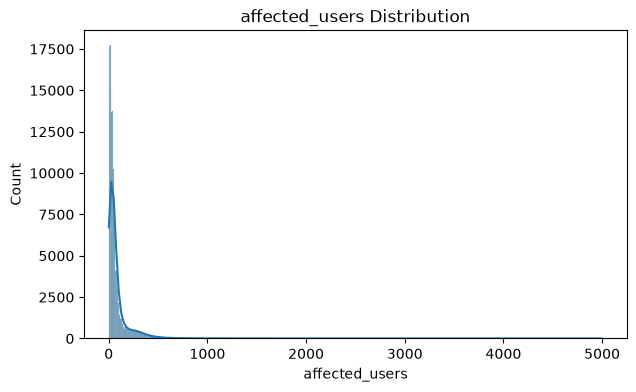

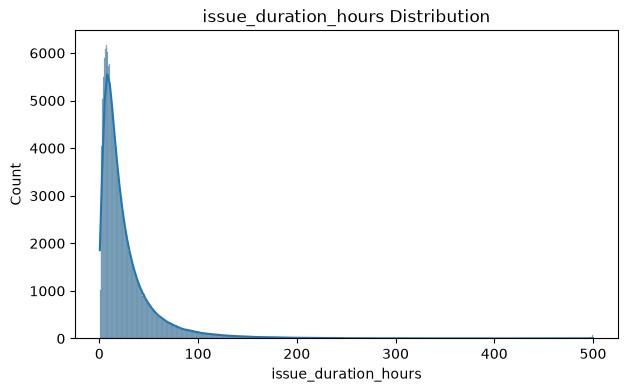

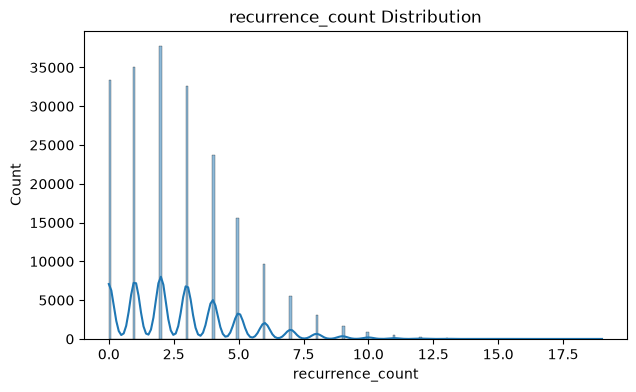

In [16]:
cols = ["affected_users", "issue_duration_hours", "recurrence_count"]

for col in cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

In [17]:
pd.crosstab(df["severity"], df["priority"])

priority,Critical,High,Low,Medium
severity,,,,
Critical,5628,516,0,13
High,12164,22136,275,6502
Low,1,442,47540,10431
Medium,960,19148,20993,53251


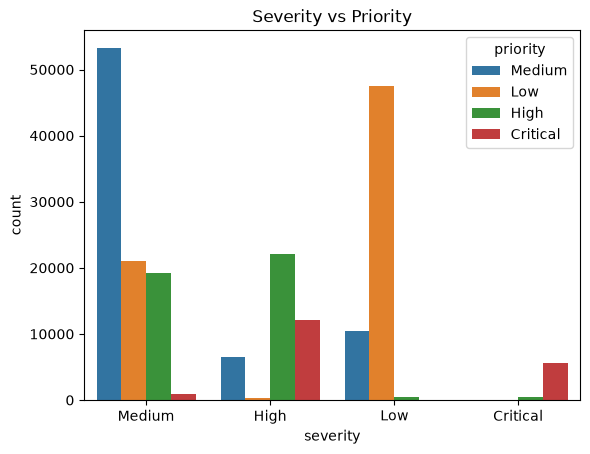

In [18]:
sns.countplot(data=df, x="severity", hue="priority")
plt.title("Severity vs Priority")
plt.show()

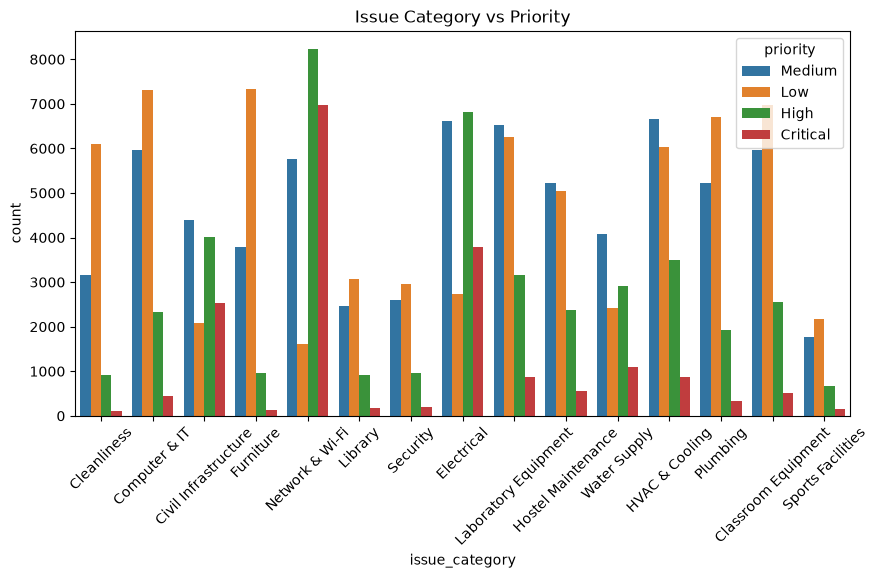

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="issue_category", hue="priority")
plt.xticks(rotation=45)
plt.title("Issue Category vs Priority")
plt.show()

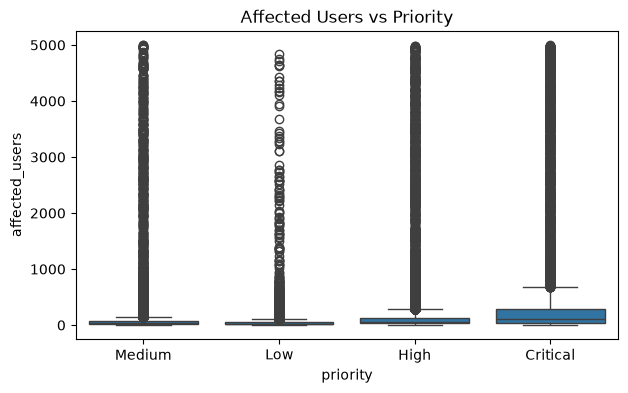

In [20]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="priority", y="affected_users")
plt.title("Affected Users vs Priority")
plt.show()

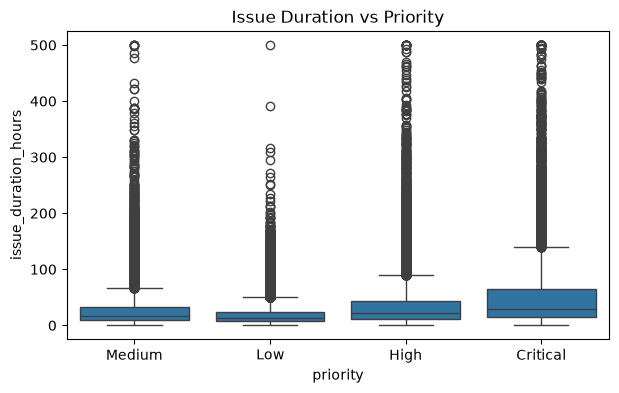

In [21]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="priority", y="issue_duration_hours")
plt.title("Issue Duration vs Priority")
plt.show()

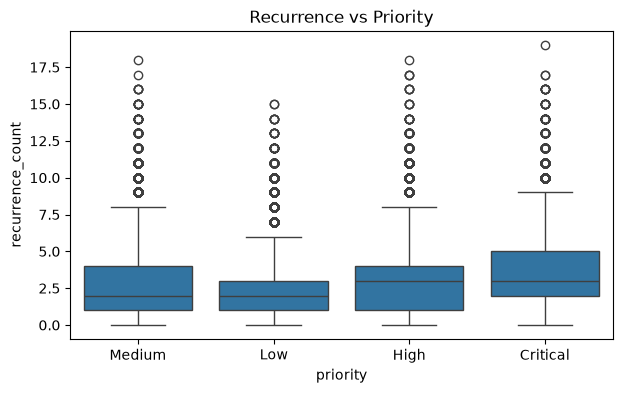

In [22]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="priority", y="recurrence_count")
plt.title("Recurrence vs Priority")
plt.show()

In [23]:
df["safety_risk"].value_counts(dropna=False)

safety_risk
NaN         88296
Low         78156
Medium      28729
High         4565
Critical      254
Name: count, dtype: int64

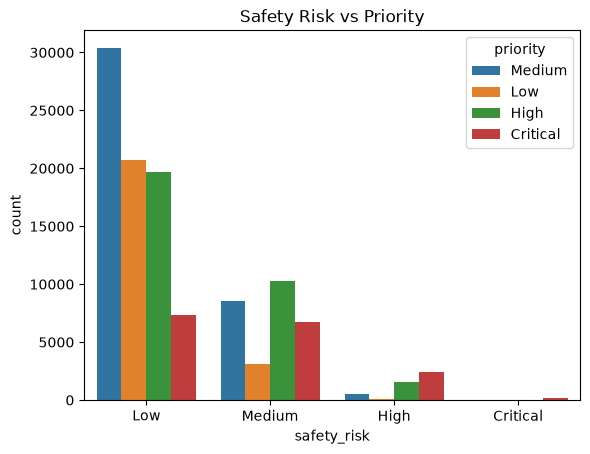

In [24]:
sns.countplot(data=df, x="safety_risk", hue="priority")
plt.title("Safety Risk vs Priority")
plt.show()

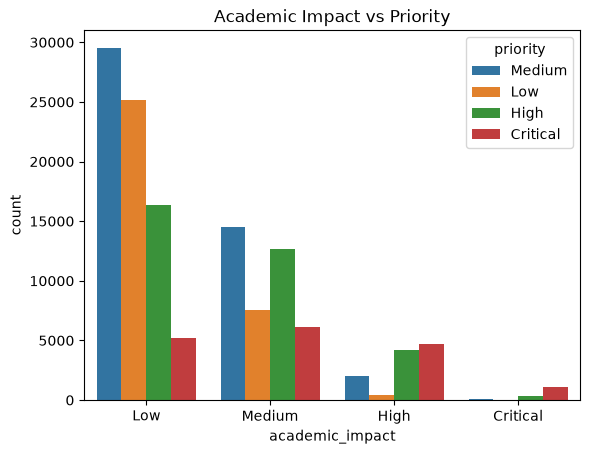

In [25]:
sns.countplot(data=df, x="academic_impact", hue="priority")
plt.title("Academic Impact vs Priority")
plt.show()

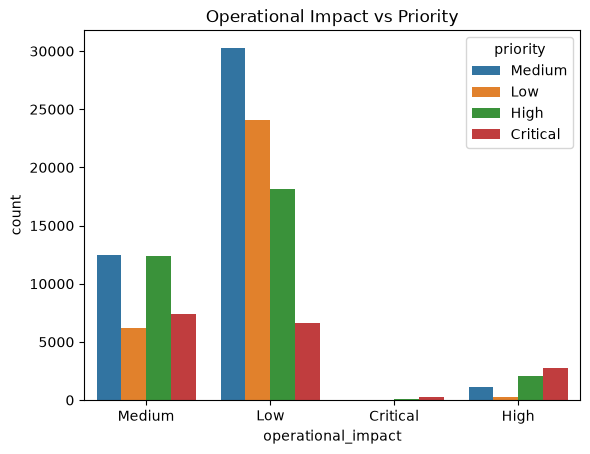

In [26]:
sns.countplot(data=df, x="operational_impact", hue="priority")
plt.title("Operational Impact vs Priority")
plt.show()

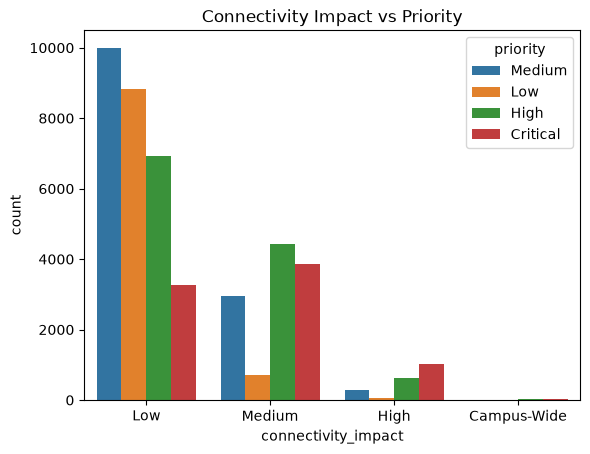

In [27]:
sns.countplot(data=df, x="connectivity_impact", hue="priority")
plt.title("Connectivity Impact vs Priority")
plt.show()

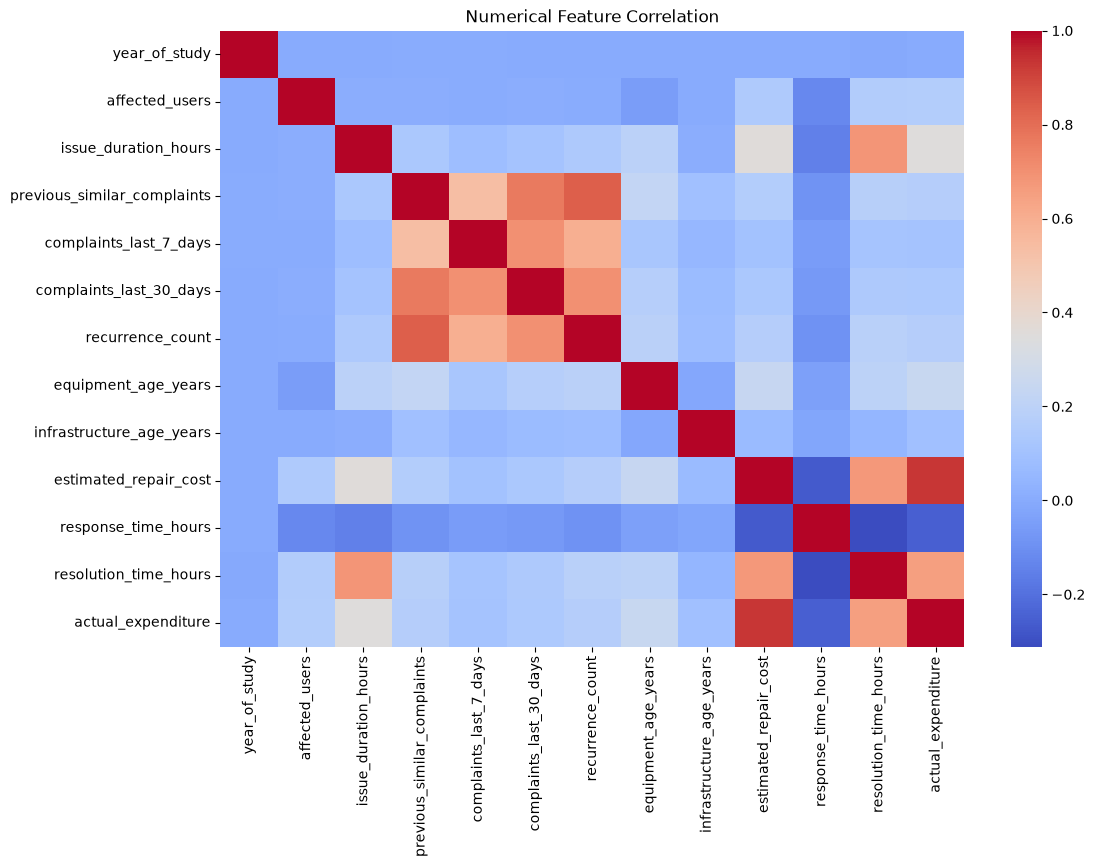

In [28]:
plt.figure(figsize=(12,8))

sns.heatmap(df[num_cols].corr(), cmap="coolwarm")

plt.title("Numerical Feature Correlation")
plt.show()

In [29]:
corr = df[num_cols].corr()

corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1]

corr_pairs.sort_values(ascending=False).head(15)

estimated_repair_cost        actual_expenditure             0.928775
actual_expenditure           estimated_repair_cost          0.928775
recurrence_count             previous_similar_complaints    0.839313
previous_similar_complaints  recurrence_count               0.839313
                             complaints_last_30_days        0.765105
complaints_last_30_days      previous_similar_complaints    0.765105
                             recurrence_count               0.702837
recurrence_count             complaints_last_30_days        0.702837
complaints_last_30_days      complaints_last_7_days         0.699138
complaints_last_7_days       complaints_last_30_days        0.699138
resolution_time_hours        issue_duration_hours           0.686238
issue_duration_hours         resolution_time_hours          0.686238
resolution_time_hours        estimated_repair_cost          0.673260
estimated_repair_cost        resolution_time_hours          0.673260
resolution_time_hours        actua

## location

In [30]:
df["building"].value_counts()

building
CS / IT Block                27118
CSIT Block                   24989
Administrative Block         20778
Lecture Theatre Complex      20045
LT Block                     17050
Lecture Rooms & Tutorials    16159
Seminar Halls                13899
Central Library              11914
Departmental Library         11621
Back Block                    9923
NLT Block                     9896
Computer Center               9815
Mechanical Block              2397
EN / EC Block                 2050
MCA Block                     1859
ME Block                       473
Common / Meeting Rooms          14
Name: count, dtype: int64

In [31]:
pd.crosstab(df["building"], df["floor"])

floor,1,2,3,4,5,Ground
building,,,,,,
Administrative Block,5298,5179,3528,663,663,5174
Back Block,2662,2502,1564,269,292,2521
CS / IT Block,5440,5502,4041,3059,3185,5571
CSIT Block,5045,5057,3627,3041,2896,5039
Central Library,3033,2992,1437,619,621,3084
Common / Meeting Rooms,6,4,0,0,0,3
Computer Center,1904,1906,1488,1174,1236,1978
Departmental Library,2858,2997,1399,613,569,3036
EN / EC Block,509,541,356,61,70,489


In [32]:
pd.crosstab(df["building"], df["facility_type"])

facility_type,AIML Lab,Administrative Office,CSE Lab,Classroom,Common Area,Computer Center,Faculty Room,IT Lab,Lecture Hall,Library,Seminar Hall,Tutorial Room,Workshop
building,,,,,,,,,,,,,
Administrative Block,0,10935,0,0,9776,0,0,0,0,0,0,0,0
Back Block,0,0,0,0,9851,0,0,0,0,0,0,0,0
CS / IT Block,3825,0,14619,0,0,0,1781,6559,0,0,0,0,0
CSIT Block,3964,0,14327,0,0,0,0,6436,0,0,0,0,0
Central Library,0,0,0,0,0,0,0,0,0,11840,0,0,0
Computer Center,0,0,0,0,0,9553,0,0,0,0,0,0,0
Departmental Library,0,0,0,0,0,0,0,0,0,11609,0,0,0
EN / EC Block,0,0,0,0,0,0,1775,0,0,0,0,0,0
LT Block,0,0,0,7297,0,0,0,0,7895,0,0,1766,0


In [33]:
pd.crosstab(df["building"], df["class_section"])

class_section,AIML-1,CE-1,CS-Hindi-1,CS1,CS2,CS3,CSE-1,CSE-2,CSE-3,CSE-AIML-1,...,S19,S2,S20,S3,S4,S5,S6,S7,S8,S9
building,,,,,,,,,,,,,,,,,,,,,
Administrative Block,1328,3975,588,136,123,142,321,336,313,0,...,91,100,122,106,118,122,112,108,123,102
Back Block,327,3829,168,141,126,129,94,92,71,0,...,39,56,47,40,36,46,54,48,48,43
CS / IT Block,26,42,7,789,790,767,2871,2891,2859,3280,...,181,156,187,181,183,188,204,160,179,177
CSIT Block,10,0,5,793,725,726,2750,2814,2826,3395,...,171,165,184,171,179,182,154,174,173,183
Central Library,457,67,224,0,0,0,363,406,385,1377,...,58,60,72,86,59,73,63,82,56,62
Common / Meeting Rooms,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
Computer Center,14,0,0,417,422,401,763,713,740,2771,...,76,54,84,57,41,64,68,82,56,68
Departmental Library,510,77,202,0,0,0,361,366,342,1362,...,58,67,63,59,62,54,67,57,66,71
EN / EC Block,1,35,3,1,1,0,65,67,59,0,...,7,6,15,11,13,16,8,9,17,18


In [34]:
df.loc[df["year_of_study"] == 1, "class_section"].value_counts()

class_section
S20    1269
S14    1264
S5     1264
S13    1254
S3     1251
S7     1248
S1     1245
S15    1244
S16    1243
S9     1237
S11    1215
S12    1211
S18    1211
S4     1209
S6     1200
S19    1188
S8     1175
S17    1158
S10    1147
S2     1137
Name: count, dtype: int64

In [35]:
df["year_of_study"].value_counts(dropna=False)

year_of_study
NaN    110634
1.0     24370
2.0     24044
3.0     22312
4.0     18640
Name: count, dtype: int64

In [36]:
df["class_section"].value_counts()

class_section
CSE-AIML-1    16803
CE-1          12696
CSE-2         10326
CSE-1         10262
CSE-3         10232
CSE-DS-1       8319
AIML-1         6882
IT-3           6822
IT-2           6816
IT-1           6798
CSIT-1         6627
ECE-3          6362
ECE-1          6329
ECE-2          6265
ME-2           5771
ME-3           5769
ME-1           5676
EN-1           5161
EN-2           5124
MCA-1          3635
CS-Hindi-1     3491
CS1            2833
CS2            2760
CS3            2697
S-11           1903
S-16           1825
S-15           1825
S-17           1773
S20            1269
S14            1264
S5             1264
S13            1254
S3             1251
S7             1248
S1             1245
S15            1244
S16            1243
S9             1237
S11            1215
S12            1211
S18            1211
S4             1209
S6             1200
S19            1188
S8             1175
S17            1158
S10            1147
S2             1137
Name: count, dtype: int64

In [37]:
df[df["department"].astype(str).str.contains("CS", case=False, na=False)]["class_section"].value_counts()

class_section
ECE-3    6362
ECE-1    6329
ECE-2    6265
EN-1     5161
EN-2     5124
S15       231
S11       224
S1        218
S14       213
S3        210
S19       209
S16       206
S9        204
S10       204
S13       203
S7        202
S2        198
S5        197
S4        197
S20       197
S12       193
S18       188
S6        188
S17       185
S8        182
Name: count, dtype: int64

In [38]:
df.groupby(["building", "floor"]).size().sort_values(ascending=False).head(20)

building                   floor 
LT Block                   Ground    5785
                           1         5743
CS / IT Block              Ground    5571
                           2         5502
                           1         5440
Administrative Block       1         5298
                           2         5179
                           Ground    5174
CSIT Block                 2         5057
                           1         5045
                           Ground    5039
Lecture Theatre Complex    1         5017
NLT Block                  Ground    4966
                           1         4930
Lecture Theatre Complex    2         4902
                           Ground    4864
CS / IT Block              3         4041
Lecture Rooms & Tutorials  1         3922
                           Ground    3845
                           2         3694
dtype: int64

In [39]:
df.groupby(["building", "facility_type"]).size().sort_values(ascending=False).head(20)

building                   facility_type        
CS / IT Block              CSE Lab                  14619
CSIT Block                 CSE Lab                  14327
Seminar Halls              Seminar Hall             13890
Central Library            Library                  11840
Departmental Library       Library                  11609
Lecture Rooms & Tutorials  Tutorial Room            11514
Administrative Block       Administrative Office    10935
Back Block                 Common Area               9851
Lecture Theatre Complex    Common Area               9850
Administrative Block       Common Area               9776
Computer Center            Computer Center           9553
LT Block                   Lecture Hall              7895
                           Classroom                 7297
CS / IT Block              IT Lab                    6559
CSIT Block                 IT Lab                    6436
Lecture Theatre Complex    Lecture Hall              5485
NLT Block              

In [40]:
pd.crosstab(df["department"],df["building"])

building,Administrative Block,Back Block,CS / IT Block,CSIT Block,Central Library,Common / Meeting Rooms,Computer Center,Departmental Library,EN / EC Block,LT Block,Lecture Rooms & Tutorials,Lecture Theatre Complex,MCA Block,ME Block,Mechanical Block,NLT Block,Seminar Halls
department,,,,,,,,,,,,,,,,,
Applied Sciences & Humanities,433,502,0,0,3229,0,0,3286,0,16,9,453,0,0,0,16,0
Artificial Intelligence & Machine Learning,1520,386,29,10,539,0,17,577,1,964,1279,891,8,0,2,532,1143
Civil Engineering,4315,4117,51,0,75,0,0,86,37,190,223,4274,45,0,55,107,181
Computer Science,473,478,2761,2628,0,0,1459,0,2,498,318,791,7,14,12,306,0
Computer Science & Information Technology,320,303,2219,2122,197,0,1277,163,4,331,215,468,2,2,7,189,0
Computer Science and Engineering,1108,288,9977,9710,1313,0,2573,1219,206,2656,1496,2024,221,0,235,1703,846
Computer Science and Engineering (Artificial Intelligence & Machine Learning),0,0,3885,4005,1642,4,3235,1606,0,1283,1410,734,11,0,0,632,1351
Computer Science and Engineering (Data Science),0,0,24,19,0,10,15,0,0,2368,2634,1186,0,0,0,1208,2400
Computer Science and Engineering (Hindi),677,191,8,5,252,0,0,230,3,572,696,468,1,0,1,328,613


In [41]:
pd.crosstab(df["campus_zone"],df["building"])

building,Administrative Block,Back Block,CS / IT Block,CSIT Block,Central Library,Common / Meeting Rooms,Computer Center,Departmental Library,EN / EC Block,LT Block,Lecture Rooms & Tutorials,Lecture Theatre Complex,MCA Block,ME Block,Mechanical Block,NLT Block,Seminar Halls
campus_zone,,,,,,,,,,,,,,,,,
Academic Block,2572,489,4244,3987,1727,5,1645,1589,328,3540,3341,2659,288,75,367,1997,3016
Administrative Block,1493,267,3247,3067,1478,0,1601,1405,244,1658,1621,1254,220,74,318,1026,1421
Auditorium Zone,644,184,1879,1633,239,4,23,214,167,1875,2115,1206,180,8,208,1021,2004
Cafeteria Zone,1924,450,1002,921,589,0,10,580,151,1193,1114,1235,134,4,117,659,901
Hostel Zone,6838,4923,3245,2849,1226,0,655,1212,338,2222,1960,6304,292,65,399,1313,1656
Laboratory Zone,1618,733,6652,6304,1165,5,2716,1150,191,3018,3030,2426,185,12,172,1690,2369
Library Zone,773,110,3287,3075,4490,0,1437,4498,268,1213,1123,847,239,4,241,771,921
Main Gate Zone,534,149,50,1,202,0,133,191,76,374,302,340,54,68,154,209,408
Parking Zone,550,132,68,0,202,0,146,204,65,340,321,351,74,58,148,201,342


## Date analysis

In [42]:
df["complaint_date"] = pd.to_datetime(df["complaint_date"],errors="coerce")

print(df["complaint_date"].min())
print(df["complaint_date"].max())

2022-01-01 00:00:00
2026-12-31 00:00:00


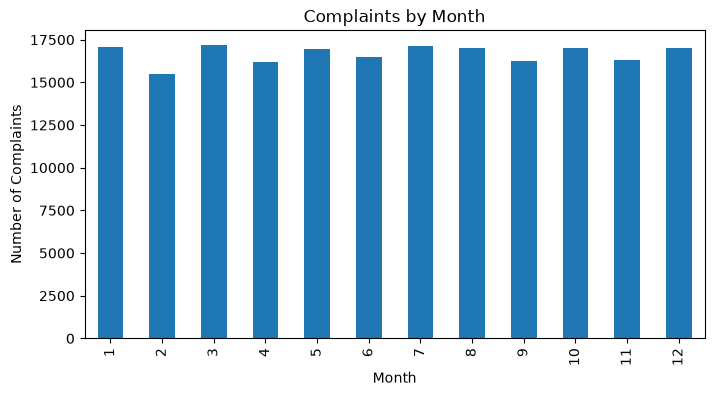

In [43]:
monthly = df["complaint_date"].dt.month.value_counts().sort_index()

monthly.plot(kind="bar", figsize=(8,4))

plt.title("Complaints by Month")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.show()

## Complaint frequency

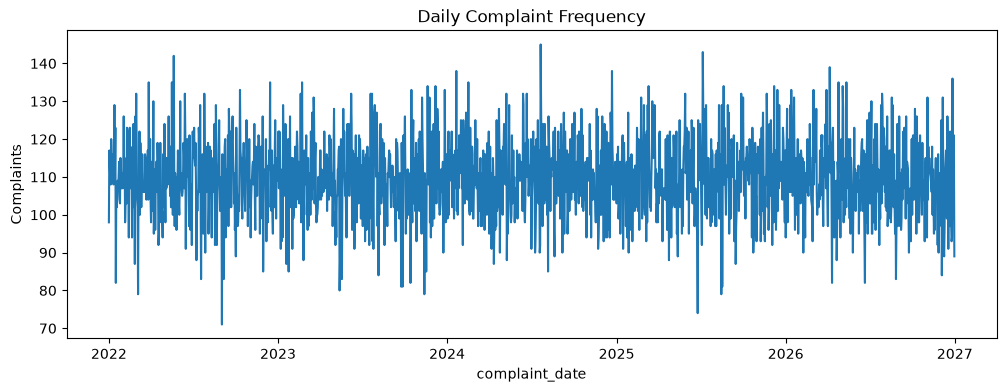

In [44]:
df.groupby(df["complaint_date"].dt.date).size().plot(figsize=(12,4))

plt.title("Daily Complaint Frequency")
plt.ylabel("Complaints")
plt.show()

## target imbalance

In [45]:
target_pct = df["priority"].value_counts(normalize=True) * 100
target_pct.round(2)

priority
Medium      35.10
Low         34.40
High        21.12
Critical     9.38
Name: proportion, dtype: float64

## Leakage

In [46]:
leakage_cols = ["complaint_status", "response_time_hours", "resolution_time_hours", "maintenance_team", "resolution_type", "actual_expenditure"]

df[leakage_cols].head()

,complaint_status,response_time_hours,resolution_time_hours,maintenance_team,resolution_type,actual_expenditure
0,Closed,9.99,12.68,Cleaning & Sanitation,Preventive Maintenance,7190
1,Closed,16.30,14.66,IT Support,Software Fix,23112
2,Closed,3.07,23.98,Civil Maintenance,Repaired,71277
3,Closed,22.66,14.10,General Maintenance,Replaced,6471
4,Resolved,5.97,25.78,Network Team,Repaired,42486


In [47]:
print(leakage_cols)

['complaint_status', 'response_time_hours', 'resolution_time_hours', 'maintenance_team', 'resolution_type', 'actual_expenditure']


In [48]:
for i, col in enumerate(df.columns, 1):
    print(i, col)

1 complaint_id
2 complaint_date
3 complaint_time
4 complainant_type
5 department
6 year_of_study
7 campus_zone
8 building
9 floor
10 room_lab_no
11 facility_type
12 class_section
13 issue_category
14 issue_subcategory
15 severity
16 affected_users
17 issue_duration_hours
18 previous_similar_complaints
19 complaints_last_7_days
20 complaints_last_30_days
21 recurrence_count
22 equipment_age_years
23 infrastructure_age_years
24 connectivity_impact
25 safety_risk
26 academic_impact
27 operational_impact
28 estimated_repair_cost
29 weather_condition
30 submission_channel
31 complaint_status
32 response_time_hours
33 resolution_time_hours
34 maintenance_team
35 resolution_type
36 priority
37 actual_expenditure


In [49]:
features = [
    "complainant_type",
    "department",
    "year_of_study",
    "campus_zone",
    "building",
    "floor",
    "room_lab_no",
    "facility_type",
    "class_section",
    "issue_category",
    "issue_subcategory",
    "severity",
    "affected_users",
    "issue_duration_hours",
    "previous_similar_complaints",
    "complaints_last_7_days",
    "complaints_last_30_days",
    "recurrence_count",
    "equipment_age_years",
    "infrastructure_age_years",
    "connectivity_impact",
    "safety_risk",
    "academic_impact",
    "operational_impact",
    "estimated_repair_cost",
    "weather_condition",
    "submission_channel"
]

In [50]:
target = "priority"

In [51]:
print("Features:", len(features))
print("Target:", target)

Features: 27
Target: priority


In [52]:
df[features].isnull().sum().sort_values(ascending=False).head(15)

connectivity_impact            156996
year_of_study                  110634
safety_risk                     88296
operational_impact              75840
academic_impact                 69964
submission_channel              10594
equipment_age_years             10223
complaints_last_30_days         10190
complaints_last_7_days           9037
issue_duration_hours             8980
issue_subcategory                8398
previous_similar_complaints      7968
weather_condition                7607
class_section                    3848
department                       2479
dtype: int64

### Leakage Decision

The following columns are excluded from priority prediction because they may contain information generated after complaint submission or during the resolution process:

- complaint_status
- response_time_hours
- resolution_time_hours
- maintenance_team
- resolution_type
- actual_expenditure

The model should make its prediction using information available when the complaint is submitted.

## EDA Summary

- The dataset contains 200,000 complaint records.
- The target variable is `priority` with four classes: Low, Medium, High and Critical.
- The target is moderately imbalanced, with Critical complaints being the minority class.
- Severity, affected users, recurrence and impact-related features are important candidates for priority prediction.
- Categorical features require encoding before ML training.
- Numerical features require appropriate preprocessing.
- Post-resolution fields such as resolution time and actual expenditure should be excluded from prediction to avoid data leakage.
- Location and section relationships were checked for consistency.

In [53]:
pca_features = [
    "affected_users",
    "issue_duration_hours",
    "previous_similar_complaints",
    "complaints_last_7_days",
    "complaints_last_30_days",
    "recurrence_count",
    "equipment_age_years",
    "infrastructure_age_years",
    "estimated_repair_cost"
]

X = df[pca_features].copy()

print(X.shape)

(200000, 9)


In [54]:
X.isnull().sum()

affected_users                     0
issue_duration_hours            8980
previous_similar_complaints     7968
complaints_last_7_days          9037
complaints_last_30_days        10190
recurrence_count                   0
equipment_age_years            10223
infrastructure_age_years           0
estimated_repair_cost              0
dtype: int64

In [55]:
X = X.fillna(X.median())

In [56]:
print(X.isnull().sum())

affected_users                 0
issue_duration_hours           0
previous_similar_complaints    0
complaints_last_7_days         0
complaints_last_30_days        0
recurrence_count               0
equipment_age_years            0
infrastructure_age_years       0
estimated_repair_cost          0
dtype: int64


In [57]:
from sklearn.preprocessing import StandardScaler

In [58]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [59]:
print(X_scaled.shape)

(200000, 9)


In [60]:
from sklearn.decomposition import PCA

In [61]:
pca = PCA()

In [62]:
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)

(200000, 9)


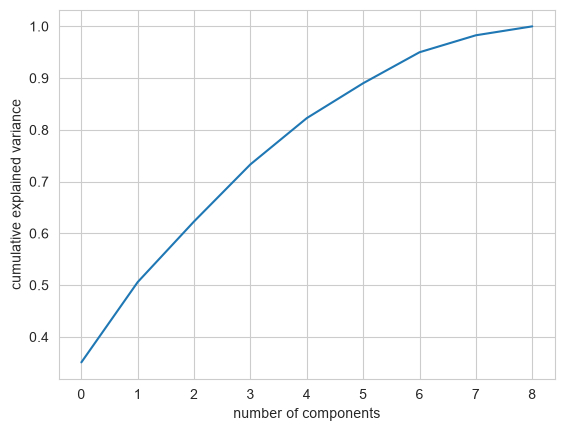

In [63]:
sns.set_style('whitegrid')
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

In [64]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.35079298 0.15515511 0.11714854 0.11028964 0.08934074 0.06738485
 0.05987226 0.03277407 0.0172418 ]


In [65]:
pca.explained_variance_ratio_.sum()

np.float64(0.9999999999999998)

In [66]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print(cumulative_variance)

[0.35079298 0.50594809 0.62309663 0.73338627 0.82272702 0.89011187
 0.94998413 0.9827582  1.        ]


In [67]:
pca= PCA(n_components=6)
pca_data_transformed = pca.fit_transform(X_scaled)

In [68]:
pca.explained_variance_ratio_.shape

(6,)

In [69]:
pca.explained_variance_ratio_

array([0.35079298, 0.15515511, 0.11714854, 0.11028964, 0.08934074,
       0.06738485])

In [70]:
pca.explained_variance_ratio_.sum()

np.float64(0.8901118695909963)

## PCA SUMMARY 

-The total number of columns from 9 have been reduced to 6 while keeping as much important information and data variance as possible.

In [71]:
print(pca_data_transformed.shape)


(200000, 6)


## K MEANS 

In [72]:
from sklearn.cluster import KMeans


In [73]:
inertia = []

for k in range(2, 11):
    
    kmeans = KMeans( n_clusters=k,random_state=42, n_init=10 )
    
    kmeans.fit(pca_data_transformed)
    
    inertia.append(kmeans.inertia_)

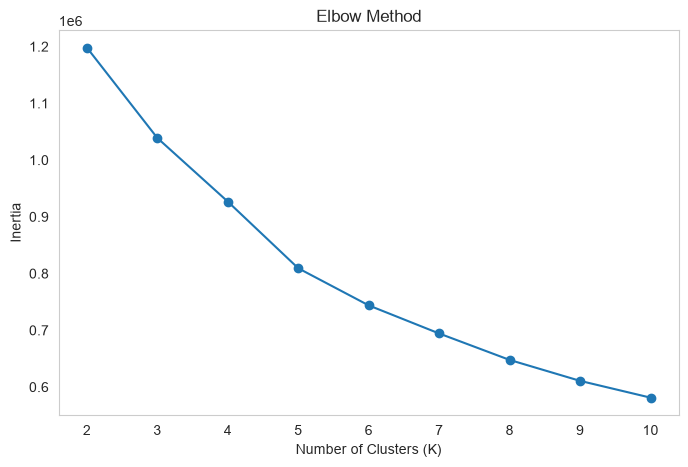

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid()

plt.show()

In [75]:
from sklearn.metrics import silhouette_score

In [76]:
silhouette_scores = []

for k in range(2, 11):

    model = KMeans(n_clusters=k, random_state=42, n_init=10)

    clusters = model.fit_predict(pca_data_transformed)

    score = silhouette_score(
        pca_data_transformed,
        clusters,
        sample_size=20000,
        random_state=42
    )

    silhouette_scores.append(score)

    print("K =", k, "Score =", round(score, 4))

K = 2 Score = 0.2965
K = 3 Score = 0.303
K = 4 Score = 0.1967
K = 5 Score = 0.2008
K = 6 Score = 0.1715
K = 7 Score = 0.1719
K = 8 Score = 0.1774
K = 9 Score = 0.1726
K = 10 Score = 0.1683


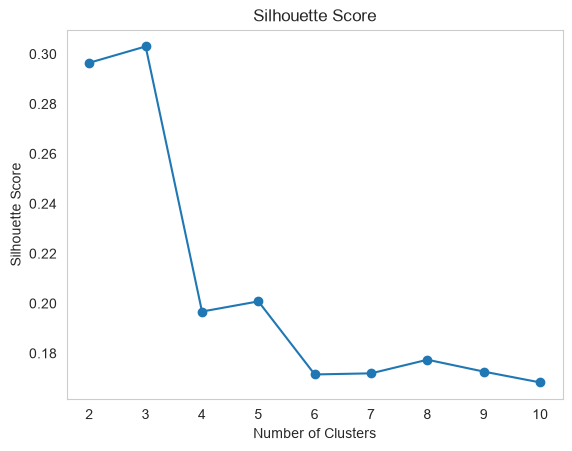

In [77]:
plt.plot(range(2, 11), silhouette_scores, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.grid()
plt.show()

In [78]:
k = 3

In [182]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(pca_data_transformed)

In [80]:
df["cluster"] = clusters

In [81]:
df.head(10)

,complaint_id,complaint_date,complaint_time,complainant_type,department,year_of_study,campus_zone,building,floor,room_lab_no,...,weather_condition,submission_channel,complaint_status,response_time_hours,resolution_time_hours,maintenance_team,resolution_type,priority,actual_expenditure,cluster
0,CP-0000001,2025-10-09,12:49:29,Student,Mechanical Engineering,4.0,Main Gate Zone,EN / EC Block,2,Faculty Room,...,Cloudy,Admin Dashboard,Closed,9.99,12.68,Cleaning & Sanitation,Preventive Maintenance,Medium,7190,1
1,CP-0000002,2024-01-08,12:21:32,Student,Computer Science and Engineering (Artificial I...,4.0,Administrative Block,CSIT Block,Ground,AIML Lab-2,...,Cloudy,Web Portal,Closed,16.30,14.66,IT Support,Software Fix,Low,23112,1
2,CP-0000003,2026-07-06,16:44:02,Maintenance Staff,Mechanical Engineering,NaN,Laboratory Zone,NLT Block,1,Classroom-301,...,Rainy,Help Desk,Closed,3.07,23.98,Civil Maintenance,Repaired,Medium,71277,1
3,CP-0000004,2023-12-17,16:03:21,Student,Electronics and Communication Engineering,1.0,Administrative Block,LT Block,1,Classroom-11,...,Cool,Help Desk,Closed,22.66,14.10,General Maintenance,Replaced,Low,6471,0
4,CP-0000005,2024-01-23,16:38:57,Administrative Staff,Computer Science and Engineering,NaN,Administrative Block,NLT Block,Ground,Classroom-302,...,Humid,Help Desk,Resolved,5.97,25.78,Network Team,Repaired,High,42486,1
5,CP-0000006,2026-05-04,18:58:42,Lab Staff,NaN,NaN,Library Zone,Central Library,2,Library,...,Cool,Mobile App,Closed,22.08,11.05,General Maintenance,Software Fix,Low,1038,1
6,CP-0000007,2024-08-13,15:22:23,Administrative Staff,Electrical and Electronics Engineering,NaN,Workshop Zone,Lecture Theatre Complex,Ground,Lecture Hall-5,...,Rainy,Mobile App,Closed,14.93,16.36,Cleaning & Sanitation,Cleaning,Medium,2349,1
7,CP-0000008,2024-11-20,13:34:42,Administrative Staff,Mechanical Engineering,NaN,Main Gate Zone,Lecture Rooms & Tutorials,1,Classroom-201,...,Sunny,Web Portal,Closed,16.98,9.85,Security Team,Repaired,Low,6263,1
8,CP-0000009,2026-08-07,15:44:47,Student,Computer Science and Engineering,1.0,Laboratory Zone,Administrative Block,1,Common Area,...,Cool,Admin Dashboard,Resolved,4.41,22.14,Electrical Team,Repaired,High,98404,0
9,CP-0000010,2025-10-19,20:46:39,Faculty,Computer Science and Engineering (Artificial I...,NaN,Academic Block,Departmental Library,4,Library,...,NaN,Help Desk,Closed,25.72,16.42,IT Support,Repaired,Medium,9541,1


In [82]:
df["cluster"].value_counts().sort_index()

cluster
0     68326
1    129918
2      1756
Name: count, dtype: int64

In [83]:
df.groupby("cluster")[pca_features].mean()

,affected_users,issue_duration_hours,previous_similar_complaints,complaints_last_7_days,complaints_last_30_days,recurrence_count,equipment_age_years,infrastructure_age_years,estimated_repair_cost
cluster,,,,,,,,,
0,79.387071,37.688137,3.305857,1.482028,4.537322,4.890276,7.367303,13.726943,19805.657905
1,77.282209,22.622351,1.132103,0.374148,1.608414,1.532582,5.521172,12.675090,11337.046275
2,3341.449317,28.843588,1.886781,0.737754,2.661290,2.635535,6.174339,13.067483,37566.604214


In [84]:
df["cluster"].value_counts().sort_index()

cluster
0     68326
1    129918
2      1756
Name: count, dtype: int64

## CLUSTERS INFO 

#Cluster 0 — Highly recurring and long-duration complaints
- Highest issue duration: 37.69 hours
- Highest previous similar complaints: 3.31
- Highest 7-day complaint frequency: 1.48
- Highest 30-day complaint frequency: 4.54
- Highest recurrence count: 4.89
- Oldest equipment on average: 7.37 years
- Relatively high repair cost: ₹19,805.66
#Cluster 1 — Less recurring and lower-cost complaints
- Lowest issue duration: 22.62 hours
- Lowest previous similar complaints: 1.13
- Lowest recent complaint frequency
- Lowest recurrence: 1.53
- Newest equipment: 5.52 years
- Lowest estimated repair cost: ₹11,337.05
#Cluster 2 — High-impact and high-cost complaints
- Extremely high affected users: 3,341.45
- Estimated repair cost is the highest: ₹37,566.60
- Moderate recurrence: 2.64
- Moderate issue duration: 28.84 hours
- Equipment and infrastructure are relatively old

## HIERARCHICAL CLUSTERING

In [85]:
from sklearn.cluster import AgglomerativeClustering

In [86]:
sample = pca_data_transformed[:5000]

In [192]:
hierarchical = AgglomerativeClustering(n_clusters=3)

hierarchical_clusters = hierarchical.fit_predict(sample)

In [193]:
print(pd.Series(hierarchical_clusters).value_counts())

0    3917
1    1025
2      58
Name: count, dtype: int64


In [194]:
score = silhouette_score(sample, hierarchical_clusters)

print("Silhouette Score =", round(score, 4))

Silhouette Score = 0.3127


In [195]:
hierarchical_df = df.iloc[:5000].copy()
hierarchical_df["cluster"] = hierarchical_clusters

hierarchical_summary = hierarchical_df.groupby("cluster")[pca_features].mean().round(2)

print(hierarchical_summary)

         affected_users  issue_duration_hours  previous_similar_complaints  \
cluster                                                                      
0                 74.72                 22.23                         1.47   
1                 74.79                 48.54                         3.51   
2               2854.03                 26.15                         1.75   

         complaints_last_7_days  complaints_last_30_days  recurrence_count  \
cluster                                                                      
0                          0.52                     2.06              2.05   
1                          1.71                     4.83              5.23   
2                          0.76                     2.63              2.41   

         equipment_age_years  infrastructure_age_years  estimated_repair_cost  
cluster                                                                        
0                       5.68                     12.88    

## Hierarchical Clustering insights

->Hierarchical Clustering identified three complaint patterns.

->Cluster 0 represents less recurring and lower-cost issues. 

->Cluster 1 represents highly recurring and longer-duration issues.

->Cluster 2 represents high-impact complaints affecting many users with higher repair costs

## DBSCAN

In [159]:
from sklearn.cluster import DBSCAN

In [160]:
sample = pca_data_transformed[:5000]

In [161]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

sample_scaled = scaler.fit_transform(sample)

In [196]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_clusters = dbscan.fit_predict(sample_scaled)

In [197]:
print("Cluster Sizes:")
print(pd.Series(dbscan_clusters).value_counts())

Cluster Sizes:
 0    4852
-1     139
 1       9
Name: count, dtype: int64


In [198]:
mask = dbscan_clusters != -1

In [200]:
score = silhouette_score(
    sample_scaled[mask],
    dbscan_clusters[mask]
)

In [201]:
print("Silhouette Score =", round(score, 4))

Silhouette Score = 0.4992


In [202]:
dbscan_df = df.iloc[:5000].copy()
dbscan_df["cluster"] = dbscan_clusters

dbscan_summary = dbscan_df.groupby("cluster")[pca_features].mean().round(2)

print(dbscan_summary)

         affected_users  issue_duration_hours  previous_similar_complaints  \
cluster                                                                      
-1              1147.94                 97.48                         2.57   
 0                74.14                 25.67                         1.88   
 1              1730.67                 26.83                         1.11   

         complaints_last_7_days  complaints_last_30_days  recurrence_count  \
cluster                                                                      
-1                         1.16                      3.7              3.95   
 0                         0.76                      2.6              2.67   
 1                         0.89                      2.0              1.33   

         equipment_age_years  infrastructure_age_years  estimated_repair_cost  
cluster                                                                        
-1                      8.12                     13.72    

## DBSCAN INSIGHTS
->DBSCAN identified two main complaint groups and a noise group.

->Cluster 0 represents regular complaints, while 

->Cluster 1 represents high-impact complaints affecting many users. 

->The noise points represent unusual complaints with very high duration, affected users, recurrence and repair cost.